# Kịch bản 2 — FD-IDS với 5 GRU + 5 Transformer

Notebook huấn luyện **federated heterogeneous models** trên CIC-IoT 2023 đã tiền xử lý, kế thừa pipeline của `10dnn/10_dnn.ipynb`.

## Thiết kế đã chốt

- 10 client non-IID, 25 feature, 34 lớp; giữ nguyên `10` communication round, `1` local epoch, batch `4096`, Adam `1e-3`.
- GRU clients: `1, 4, 5, 7, 8` (19.068.139 mẫu).
- Transformer clients: `2, 3, 6, 9, 10` (16.946.455 mẫu).
- Vì hai kiến trúc không thể FedAvg trực tiếp, notebook duy trì **hai global model** và weighted-FedAvg riêng trong từng họ.
- Teacher KD là trung bình phân phối xác suất của global GRU và global Transformer. Cách này cho phép trao đổi tri thức qua logits dù tham số khác cấu trúc.
- FedProx ràng buộc mỗi local model với global model cùng họ.
- Đánh giá ba predictor: GRU, Transformer, và ensemble trung bình xác suất của hai model.
- Lưu cả best checkpoint theo **weighted-F1** (so sánh trực tiếp baseline) và **macro-F1** (theo dõi lớp thiểu số).

## Kaggle runtime

Chọn accelerator **GPU T4 x2**. Mỗi local model dùng `nn.DataParallel` trên đúng hai GPU và mixed precision. Dữ liệu CSV đã được QuantileTransformer từ bước preprocessing nên notebook không scale lại.


In [1]:
# ===== Cell 1: Kiểm tra môi trường Kaggle GPU T4 x2 =====
import platform
import sys

import torch

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

N_GPU = torch.cuda.device_count()
for index in range(N_GPU):
    props = torch.cuda.get_device_properties(index)
    print(f"GPU[{index}]: {props.name} | memory={props.total_memory / 1e9:.1f} GB")

assert torch.cuda.is_available(), "Hãy bật GPU accelerator trong Kaggle Settings."
assert N_GPU == 2, "Notebook yêu cầu đúng accelerator GPU T4 x2."
assert all("T4" in torch.cuda.get_device_name(i) for i in range(N_GPU)), (
    "Hai GPU phải là NVIDIA T4. Hãy chọn GPU T4 x2 trong Kaggle Settings."
)

torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda:0")


Python: 3.12.13
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
PyTorch: 2.10.0+cu128
CUDA available: True
GPU[0]: Tesla T4 | memory=15.6 GB
GPU[1]: Tesla T4 | memory=15.6 GB


In [2]:
# ===== Cell 2: Import, CONFIG, seed, output layout và logger =====
import gc
import json
import logging
import math
import random
import sys
import time
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

CONFIG = {
    "input_dir": Path("/kaggle/input/datasets/odixe0502/data-for-10clients"),
    "run_name": "fdids_gru_transformer_run1",
    "num_clients": 10,
    "input_dim": 25,
    "num_classes": 34,
    "target_column": "Label",
    "client_families": {
        "gru": [1, 4, 5, 7, 8],
        "transformer": [2, 3, 6, 9, 10],
    },
    "gru_hidden_size": 48,
    "gru_num_layers": 2,
    "transformer_d_model": 32,
    "transformer_nhead": 4,
    "transformer_num_layers": 2,
    "transformer_ff_dim": 64,
    "dropout": 0.0,
    "local_epochs": 1,
    "communication_rounds": 10,
    "batch_size": 4096,
    "eval_batch_size": 16384,
    "learning_rate": 1e-3,
    "weight_decay": 0.0,
    "temperature": 3.0,
    "lambda_hard": 0.5,
    "mu_prox": 0.01,
    "beta_prox": 0.1,
    "quick_eval_size": 10_000,
    "num_workers": 0,
    "pin_memory": True,
    "seed": 42,
    "amp": True,
    "max_samples_per_client": None,
    "max_debug_batches": None,
    "log_every": 200,
    "resume": False,
}


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(CONFIG["seed"])
assert CONFIG["batch_size"] % N_GPU == 0, "Global batch phải chia hết cho 2 GPU."
assert sorted(CONFIG["client_families"]["gru"] + CONFIG["client_families"]["transformer"]) == list(range(1, 11))

OUT = Path("/kaggle/working") / CONFIG["run_name"]
TEMP_DIR = Path("/kaggle/temp") / CONFIG["run_name"]
for directory in ("checkpoints", "logs", "metrics", "artifacts"):
    (OUT / directory).mkdir(parents=True, exist_ok=True)
TEMP_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = OUT / "checkpoints"
METRICS_DIR = OUT / "metrics"
ARTIFACT_DIR = OUT / "artifacts"
HISTORY_FILE = METRICS_DIR / "history.csv"
LOG_FILE = OUT / "logs" / "run.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[logging.FileHandler(LOG_FILE), logging.StreamHandler(sys.stdout)],
    force=True,
)
logger = logging.getLogger("fdids_heterogeneous")


def jsonable(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {str(k): jsonable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [jsonable(v) for v in value]
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    return value


(METRICS_DIR / "config.json").write_text(
    json.dumps(jsonable(CONFIG), indent=2, ensure_ascii=False), encoding="utf-8"
)
logger.info("Run %s started", CONFIG["run_name"])
logger.info("GPUs: %s", [torch.cuda.get_device_name(i) for i in range(N_GPU)])
logger.info("Resolved CONFIG: %s", json.dumps(jsonable(CONFIG), sort_keys=True))
logger.info("Output root: %s", OUT)


2026-07-18 20:30:35 | INFO | Run fdids_gru_transformer_run1 started
2026-07-18 20:30:35 | INFO | GPUs: ['Tesla T4', 'Tesla T4']
2026-07-18 20:30:35 | INFO | Resolved CONFIG: {"amp": true, "batch_size": 4096, "beta_prox": 0.1, "client_families": {"gru": [1, 4, 5, 7, 8], "transformer": [2, 3, 6, 9, 10]}, "communication_rounds": 10, "dropout": 0.0, "eval_batch_size": 16384, "gru_hidden_size": 48, "gru_num_layers": 2, "input_dim": 25, "input_dir": "/kaggle/input/datasets/odixe0502/data-for-10clients", "lambda_hard": 0.5, "learning_rate": 0.001, "local_epochs": 1, "log_every": 200, "max_debug_batches": null, "max_samples_per_client": null, "mu_prox": 0.01, "num_classes": 34, "num_clients": 10, "num_workers": 0, "pin_memory": true, "quick_eval_size": 10000, "resume": false, "run_name": "fdids_gru_transformer_run1", "seed": 42, "target_column": "Label", "temperature": 3.0, "transformer_d_model": 32, "transformer_ff_dim": 64, "transformer_nhead": 4, "transformer_num_layers": 2, "weight_decay":

In [3]:
# ===== Cell 3: Xác thực contract và load 10 client + global test =====
CLIENT_FILES = {
    client_id: CONFIG["input_dir"] / f"client_{client_id}_train.csv"
    for client_id in range(1, CONFIG["num_clients"] + 1)
}
TEST_FILE = CONFIG["input_dir"] / "global_test_data.csv"
MAPPING_FILE = CONFIG["input_dir"] / "label_mapping.csv"


def load_label_mapping(path):
    frame = pd.read_csv(path)
    required = {"Encoded_ID", "Label_Name"}
    assert required.issubset(frame.columns), f"{path.name} phải có các cột {sorted(required)}"
    label_to_id = dict(zip(frame["Label_Name"].astype(str), frame["Encoded_ID"].astype(int)))
    id_to_label = dict(zip(frame["Encoded_ID"].astype(int), frame["Label_Name"].astype(str)))
    return label_to_id, id_to_label


def labels_to_tensor(series, label_to_id):
    if pd.api.types.is_numeric_dtype(series):
        values = series.to_numpy(dtype=np.int64, copy=True)
    else:
        mapped = series.astype(str).map(label_to_id)
        if mapped.isna().any():
            unknown = sorted(series.astype(str)[mapped.isna()].unique().tolist())[:10]
            raise ValueError(f"Nhãn chưa có trong label_mapping.csv: {unknown}")
        values = mapped.to_numpy(dtype=np.int64, copy=True)
    return torch.as_tensor(values, dtype=torch.long)


def load_csv_tensors(path, feature_columns, target_column, label_to_id):
    dtypes = {column: "float32" for column in feature_columns}
    frame = pd.read_csv(path, dtype=dtypes)
    features = torch.from_numpy(
        frame[feature_columns].to_numpy(dtype=np.float32, copy=True)
    )
    targets = labels_to_tensor(frame[target_column], label_to_id)
    del frame
    gc.collect()
    if not torch.isfinite(features).all():
        logger.warning("%s có NaN/Inf; thay bằng 0 để tránh lỗi runtime.", path.name)
        features = torch.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    if targets.numel() and (int(targets.min()) < 0 or int(targets.max()) >= CONFIG["num_classes"]):
        raise ValueError(
            f"{path.name}: label ngoài [0, {CONFIG['num_classes'] - 1}] "
            f"(min={int(targets.min())}, max={int(targets.max())})"
        )
    return features.contiguous(), targets.contiguous()


try:
    required_files = list(CLIENT_FILES.values()) + [TEST_FILE, MAPPING_FILE]
    missing = [str(path) for path in required_files if not path.exists()]
    assert not missing, f"Thiếu file input: {missing}"

    label_to_id, id_to_label = load_label_mapping(MAPPING_FILE)
    assert len(id_to_label) == CONFIG["num_classes"], (
        f"Mapping có {len(id_to_label)} lớp, kỳ vọng {CONFIG['num_classes']}"
    )

    first_header = pd.read_csv(CLIENT_FILES[1], nrows=0).columns.tolist()
    assert CONFIG["target_column"] in first_header, f"Thiếu cột {CONFIG['target_column']}"
    FEATURE_COLUMNS = [c for c in first_header if c != CONFIG["target_column"]]
    assert len(FEATURE_COLUMNS) == CONFIG["input_dim"], (
        f"Có {len(FEATURE_COLUMNS)} feature, kỳ vọng {CONFIG['input_dim']}"
    )
    for path in list(CLIENT_FILES.values()) + [TEST_FILE]:
        header = pd.read_csv(path, nrows=0).columns.tolist()
        assert header == first_header, f"Schema không đồng nhất: {path.name}"

    logger.info("Validated dataset: 25 features, target=%s, classes=%d", CONFIG["target_column"], len(id_to_label))
    logger.info("Feature order used as sequence tokens: %s", FEATURE_COLUMNS)

    CLIENT_DATA = {}
    CLIENT_COUNTS = {}
    load_start = time.time()
    for client_id, path in CLIENT_FILES.items():
        x_client, y_client = load_csv_tensors(
            path, FEATURE_COLUMNS, CONFIG["target_column"], label_to_id
        )
        CLIENT_DATA[client_id] = (x_client, y_client)
        CLIENT_COUNTS[client_id] = len(y_client)
        family = "gru" if client_id in CONFIG["client_families"]["gru"] else "transformer"
        logger.info(
            "Loaded client %02d | family=%s | X=%s | samples=%d | elapsed=%.1fs",
            client_id, family, tuple(x_client.shape), len(y_client), time.time() - load_start,
        )

    expected_counts = {
        1: 31_520, 2: 2_211_589, 3: 3_728_450, 4: 1_920_254, 5: 2_531_881,
        6: 2_686_617, 7: 1_824_975, 8: 12_759_509, 9: 4_354_192, 10: 3_965_607,
    }
    assert CLIENT_COUNTS == expected_counts, (
        f"Số mẫu client khác data_description.md: actual={CLIENT_COUNTS}"
    )

    X_TEST, Y_TEST = load_csv_tensors(
        TEST_FILE, FEATURE_COLUMNS, CONFIG["target_column"], label_to_id
    )
    logger.info("Loaded global test | X=%s | samples=%d", tuple(X_TEST.shape), len(Y_TEST))

    from sklearn.model_selection import train_test_split

    all_indices = np.arange(len(Y_TEST))
    quick_size = min(CONFIG["quick_eval_size"], len(all_indices))
    try:
        _, quick_indices = train_test_split(
            all_indices,
            test_size=quick_size,
            stratify=Y_TEST.numpy(),
            random_state=CONFIG["seed"],
        )
        quick_sampling = "stratified"
    except ValueError:
        rng = np.random.default_rng(CONFIG["seed"])
        quick_indices = rng.choice(all_indices, size=quick_size, replace=False)
        quick_sampling = "random fallback"
    quick_indices = np.sort(quick_indices)
    X_QUICK = X_TEST[quick_indices].contiguous()
    Y_QUICK = Y_TEST[quick_indices].contiguous()
    np.save(METRICS_DIR / "quick_eval_indices.npy", quick_indices)
    logger.info(
        "Quick evaluation subset: %d samples | %s | represented classes=%d/%d",
        len(Y_QUICK), quick_sampling, len(torch.unique(Y_QUICK)), CONFIG["num_classes"],
    )

    family_counts = {
        family: sum(CLIENT_COUNTS[cid] for cid in client_ids)
        for family, client_ids in CONFIG["client_families"].items()
    }
    logger.info("Family sample counts: %s", family_counts)
except Exception:
    logger.error("Dataset stage failed:\n%s", traceback.format_exc())
    raise


2026-07-18 20:30:35 | INFO | Validated dataset: 25 features, target=Label, classes=34
2026-07-18 20:30:35 | INFO | Feature order used as sequence tokens: ['ack_flag_number', 'AVG', 'Std', 'UDP', 'fin_count', 'Max', 'TCP', 'syn_count', 'Protocol Type', 'Rate', 'IAT', 'syn_flag_number', 'rst_flag_number', 'Tot sum', 'HTTPS', 'ack_count', 'fin_flag_number', 'HTTP', 'rst_count', 'Header_Length', 'psh_flag_number', 'ICMP', 'Time_To_Live', 'ARP', 'DNS']
2026-07-18 20:30:35 | INFO | Loaded client 01 | family=gru | X=(31520, 25) | samples=31520 | elapsed=0.3s
2026-07-18 20:30:44 | INFO | Loaded client 02 | family=transformer | X=(2211589, 25) | samples=2211589 | elapsed=8.6s
2026-07-18 20:30:58 | INFO | Loaded client 03 | family=transformer | X=(3728450, 25) | samples=3728450 | elapsed=22.4s
2026-07-18 20:31:05 | INFO | Loaded client 04 | family=gru | X=(1920254, 25) | samples=1920254 | elapsed=29.6s
2026-07-18 20:31:14 | INFO | Loaded client 05 | family=gru | X=(2531881, 25) | samples=2531881

In [4]:
# ===== Cell 4: Định nghĩa GRU, Transformer và DataParallel =====
class FeatureGRU(nn.Module):
    """Xem 25 feature có thứ tự cố định như chuỗi 25 scalar token."""

    def __init__(self, input_dim, hidden_size, num_layers, num_classes, dropout=0.0):
        super().__init__()
        self.input_dim = input_dim
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, features):
        sequence = features.unsqueeze(-1)
        _, hidden = self.gru(sequence)
        return self.classifier(hidden[-1])


class FeatureTransformer(nn.Module):
    """Project mỗi scalar feature thành token và attention trên 25 feature token."""

    def __init__(
        self, input_dim, d_model, nhead, num_layers, ff_dim, num_classes, dropout=0.0
    ):
        super().__init__()
        self.input_dim = input_dim
        self.value_projection = nn.Linear(1, d_model)
        self.feature_embedding = nn.Parameter(torch.zeros(1, input_dim, d_model))
        nn.init.normal_(self.feature_embedding, mean=0.0, std=0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="relu",
            batch_first=True,
            norm_first=False,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, features):
        tokens = self.value_projection(features.unsqueeze(-1)) + self.feature_embedding
        encoded = self.encoder(tokens)
        return self.classifier(encoded.mean(dim=1))


def build_model(family):
    if family == "gru":
        return FeatureGRU(
            CONFIG["input_dim"],
            CONFIG["gru_hidden_size"],
            CONFIG["gru_num_layers"],
            CONFIG["num_classes"],
            CONFIG["dropout"],
        )
    if family == "transformer":
        return FeatureTransformer(
            CONFIG["input_dim"],
            CONFIG["transformer_d_model"],
            CONFIG["transformer_nhead"],
            CONFIG["transformer_num_layers"],
            CONFIG["transformer_ff_dim"],
            CONFIG["num_classes"],
            CONFIG["dropout"],
        )
    raise ValueError(f"Unknown family: {family}")


def unwrap(model):
    return model.module if isinstance(model, nn.DataParallel) else model


def wrap_data_parallel(model):
    model = model.to(DEVICE)
    return nn.DataParallel(model, device_ids=[0, 1], output_device=0)


def state_to_cpu(model):
    return {name: tensor.detach().cpu().clone() for name, tensor in unwrap(model).state_dict().items()}


try:
    PARAMETER_COUNTS = {}
    INITIAL_STATES = {}
    for family in ("gru", "transformer"):
        model = build_model(family)
        PARAMETER_COUNTS[family] = sum(p.numel() for p in model.parameters() if p.requires_grad)
        INITIAL_STATES[family] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        with torch.no_grad():
            logits = model(X_QUICK[:16])
        assert logits.shape == (16, CONFIG["num_classes"])
        assert torch.isfinite(logits).all(), f"{family} forward có NaN/Inf"
        logger.info(
            "%s forward smoke test OK | parameters=%d | fp32 size=%.3f MB",
            family.upper(), PARAMETER_COUNTS[family], PARAMETER_COUNTS[family] * 4 / 1e6,
        )
        del model, logits

    (METRICS_DIR / "model_parameters.json").write_text(
        json.dumps(PARAMETER_COUNTS, indent=2), encoding="utf-8"
    )
except Exception:
    logger.error("Model definition stage failed:\n%s", traceback.format_exc())
    raise


2026-07-18 20:33:26 | INFO | GRU forward smoke test OK | parameters=23122 | fp32 size=0.092 MB
2026-07-18 20:33:26 | INFO | TRANSFORMER forward smoke test OK | parameters=19074 | fp32 size=0.076 MB


In [5]:
# ===== Cell 5: DataLoader, cross-family KD, FedProx và local training =====
def make_loader(features, targets, batch_size, shuffle, seed):
    generator = torch.Generator()
    generator.manual_seed(seed)
    dataset = TensorDataset(features, targets)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=CONFIG["num_workers"],
        pin_memory=CONFIG["pin_memory"],
        drop_last=False,
        generator=generator if shuffle else None,
    )


def proximal_term(student_core, global_reference):
    total = torch.zeros((), device=DEVICE, dtype=torch.float32)
    for name, parameter in student_core.named_parameters():
        total = total + (parameter.float() - global_reference[name]).pow(2).sum()
    return (CONFIG["mu_prox"] / 2.0) * total


def make_grad_scaler(enabled=True):
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (TypeError, AttributeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def build_teacher_pair(states):
    teachers = {}
    for family in ("gru", "transformer"):
        teacher = wrap_data_parallel(build_model(family))
        unwrap(teacher).load_state_dict(states[family])
        teacher.eval()
        for parameter in teacher.parameters():
            parameter.requires_grad_(False)
        teachers[family] = teacher
    return teachers


def train_one_client(client_id, family, global_state, teachers, features, targets, round_index, config=CONFIG):
    start_time = time.time()
    student = wrap_data_parallel(build_model(family))
    unwrap(student).load_state_dict(global_state)
    student.train()
    student_core = unwrap(student)
    global_reference = {
        name: parameter.detach().float().clone()
        for name, parameter in student_core.named_parameters()
    }
    optimizer = torch.optim.Adam(
        student.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )
    scaler = make_grad_scaler(config["amp"])

    if config["max_samples_per_client"] is not None and len(targets) > config["max_samples_per_client"]:
        subset_generator = torch.Generator().manual_seed(config["seed"] + round_index * 100 + client_id)
        subset = torch.randperm(len(targets), generator=subset_generator)[: config["max_samples_per_client"]]
        features_used, targets_used = features[subset], targets[subset]
    else:
        features_used, targets_used = features, targets

    loader = make_loader(
        features_used,
        targets_used,
        config["batch_size"],
        shuffle=True,
        seed=config["seed"] + round_index * 100 + client_id,
    )
    loss_sum = 0.0
    examples_seen = 0
    batches_seen = 0

    for local_epoch in range(config["local_epochs"]):
        for batch_index, (batch_features, batch_targets) in enumerate(loader):
            if config["max_debug_batches"] is not None and batch_index >= config["max_debug_batches"]:
                break
            batch_features = batch_features.to(DEVICE, non_blocking=True)
            batch_targets = batch_targets.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=config["amp"]):
                with torch.no_grad():
                    gru_teacher_logits = teachers["gru"](batch_features)
                    transformer_teacher_logits = teachers["transformer"](batch_features)
                student_logits = student(batch_features)

            temperature = config["temperature"]
            with torch.no_grad():
                teacher_probabilities = 0.5 * (
                    F.softmax(gru_teacher_logits.float() / temperature, dim=1)
                    + F.softmax(transformer_teacher_logits.float() / temperature, dim=1)
                )
            hard_loss = F.cross_entropy(student_logits.float(), batch_targets)
            soft_loss = (temperature ** 2) * F.kl_div(
                F.log_softmax(student_logits.float() / temperature, dim=1),
                teacher_probabilities,
                reduction="batchmean",
            )
            prox_loss = proximal_term(student_core, global_reference)
            total_loss = (
                config["lambda_hard"] * hard_loss
                + (1.0 - config["lambda_hard"]) * soft_loss
                + config["beta_prox"] * prox_loss
            )

            scaler.scale(total_loss).backward()
            scaler.step(optimizer)
            scaler.update()

            batch_n = len(batch_targets)
            loss_sum += float(total_loss.detach()) * batch_n
            examples_seen += batch_n
            batches_seen += 1
            if config["log_every"] and batch_index % config["log_every"] == 0:
                logger.info(
                    "Round %02d | %s client %02d | epoch %d | batch %d/%d | loss=%.6f",
                    round_index, family, client_id, local_epoch + 1, batch_index, len(loader), float(total_loss.detach()),
                )

    if examples_seen == 0:
        raise RuntimeError(f"Client {client_id} không xử lý batch nào")
    local_state = state_to_cpu(student)
    average_loss = loss_sum / examples_seen
    elapsed = time.time() - start_time
    del student, student_core, optimizer, scaler, global_reference, loader
    torch.cuda.empty_cache()
    return {
        "client_id": client_id,
        "family": family,
        "state": local_state,
        "samples": len(targets_used),
        "examples_seen": examples_seen,
        "batches": batches_seen,
        "loss": average_loss,
        "seconds": elapsed,
    }


try:
    smoke_config = dict(CONFIG)
    smoke_config["batch_size"] = 512
    smoke_config["max_samples_per_client"] = 512
    smoke_config["max_debug_batches"] = 1
    smoke_teachers = build_teacher_pair(INITIAL_STATES)
    smoke_result = train_one_client(
        0, "gru", INITIAL_STATES["gru"], smoke_teachers,
        X_QUICK, Y_QUICK, round_index=0, config=smoke_config,
    )
    assert set(smoke_result["state"]) == set(INITIAL_STATES["gru"])
    assert math.isfinite(smoke_result["loss"])
    logger.info("DataParallel + AMP + KD + FedProx backward smoke test OK | loss=%.6f", smoke_result["loss"])
    del smoke_teachers, smoke_result
    torch.cuda.empty_cache()
except Exception:
    logger.error("Local training smoke test failed:\n%s", traceback.format_exc())
    raise


2026-07-18 20:33:29 | INFO | Round 00 | gru client 00 | epoch 1 | batch 0/1 | loss=1.765374
2026-07-18 20:33:29 | INFO | DataParallel + AMP + KD + FedProx backward smoke test OK | loss=1.765374


In [6]:
# ===== Cell 6: Family-wise FedAvg và đánh giá GRU/Transformer/ensemble =====
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)


def weighted_fedavg(client_results):
    total_samples = sum(result["samples"] for result in client_results)
    if total_samples <= 0:
        raise ValueError("Không có mẫu để aggregate")
    aggregated = None
    for result in client_results:
        weight = result["samples"] / total_samples
        state = result["state"]
        if aggregated is None:
            aggregated = {name: tensor.detach().float() * weight for name, tensor in state.items()}
        else:
            for name in aggregated:
                aggregated[name].add_(state[name].detach().float(), alpha=weight)
    return aggregated


def classification_scores(y_true, y_pred):
    labels = list(range(CONFIG["num_classes"]))
    macro = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, average="macro", zero_division=0
    )
    weighted = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, average="weighted", zero_division=0
    )
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_precision": float(macro[0]),
        "macro_recall": float(macro[1]),
        "macro_f1": float(macro[2]),
        "weighted_precision": float(weighted[0]),
        "weighted_recall": float(weighted[1]),
        "weighted_f1": float(weighted[2]),
    }


def attack_vs_benign(y_true, y_pred):
    benign_ids = [idx for idx, name in id_to_label.items() if name.upper().startswith("BENIGN")]
    if not benign_ids:
        return {}
    benign_id = int(benign_ids[0])
    true_attack = np.asarray(y_true) != benign_id
    pred_attack = np.asarray(y_pred) != benign_id
    tp = int((true_attack & pred_attack).sum())
    fn = int((true_attack & ~pred_attack).sum())
    fp = int((~true_attack & pred_attack).sum())
    tn = int((~true_attack & ~pred_attack).sum())
    return {
        "benign_id": benign_id,
        "TP": tp,
        "FN": fn,
        "FP": fp,
        "TN": tn,
        "FPR": fp / (fp + tn) if fp + tn else 0.0,
        "FNR": fn / (fn + tp) if fn + tp else 0.0,
        "attack_detection_rate": tp / (tp + fn) if tp + fn else 0.0,
    }


@torch.no_grad()
def evaluate_triplet(states, features, targets):
    models = {}
    for family in ("gru", "transformer"):
        model = wrap_data_parallel(build_model(family))
        unwrap(model).load_state_dict(states[family])
        model.eval()
        models[family] = model

    loader = make_loader(
        features,
        targets,
        CONFIG["eval_batch_size"],
        shuffle=False,
        seed=CONFIG["seed"],
    )
    predictions = {"gru": [], "transformer": [], "ensemble": []}
    loss_sums = {"gru": 0.0, "transformer": 0.0, "ensemble": 0.0}
    examples = 0

    for batch_features, batch_targets in loader:
        batch_features = batch_features.to(DEVICE, non_blocking=True)
        batch_targets = batch_targets.to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=CONFIG["amp"]):
            gru_logits = models["gru"](batch_features)
            transformer_logits = models["transformer"](batch_features)
        gru_logits = gru_logits.float()
        transformer_logits = transformer_logits.float()
        gru_probabilities = F.softmax(gru_logits, dim=1)
        transformer_probabilities = F.softmax(transformer_logits, dim=1)
        ensemble_probabilities = 0.5 * (gru_probabilities + transformer_probabilities)

        batch_n = len(batch_targets)
        loss_sums["gru"] += float(F.cross_entropy(gru_logits, batch_targets, reduction="sum"))
        loss_sums["transformer"] += float(F.cross_entropy(transformer_logits, batch_targets, reduction="sum"))
        loss_sums["ensemble"] += float(
            F.nll_loss(ensemble_probabilities.clamp_min(1e-8).log(), batch_targets, reduction="sum")
        )
        predictions["gru"].append(gru_logits.argmax(dim=1).cpu())
        predictions["transformer"].append(transformer_logits.argmax(dim=1).cpu())
        predictions["ensemble"].append(ensemble_probabilities.argmax(dim=1).cpu())
        examples += batch_n

    y_true = targets.numpy()
    output = {"y_true": y_true, "predictions": {}, "losses": {}, "metrics": {}, "attack_vs_benign": {}}
    for predictor in predictions:
        y_pred = torch.cat(predictions[predictor]).numpy()
        output["predictions"][predictor] = y_pred
        output["losses"][predictor] = loss_sums[predictor] / examples
        output["metrics"][predictor] = classification_scores(y_true, y_pred)
        output["attack_vs_benign"][predictor] = attack_vs_benign(y_true, y_pred)

    del models, loader
    torch.cuda.empty_cache()
    return output


def flatten_quick_metrics(round_index, family_losses, evaluation, round_seconds):
    row = {
        "round": round_index,
        "gru_train_loss": family_losses["gru"],
        "transformer_train_loss": family_losses["transformer"],
        "round_time_sec": round_seconds,
    }
    for predictor in ("gru", "transformer", "ensemble"):
        row[f"{predictor}_eval_loss"] = evaluation["losses"][predictor]
        for metric_name, metric_value in evaluation["metrics"][predictor].items():
            row[f"{predictor}_{metric_name}"] = metric_value
    return row


def checkpoint_bundle(round_index, states, row):
    return {
        "round": int(round_index),
        "gru": {k: v.detach().cpu().clone() for k, v in states["gru"].items()},
        "transformer": {k: v.detach().cpu().clone() for k, v in states["transformer"].items()},
        "quick_metrics": dict(row),
        "config": jsonable(CONFIG),
    }


def load_checkpoint(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


logger.info("Aggregation and evaluation helpers ready")


2026-07-18 20:33:29 | INFO | Aggregation and evaluation helpers ready


In [7]:
# ===== Cell 7: Main loop — family-wise FedAvg + cross-family round-wise KD =====
history = []

try:
    if CONFIG["resume"]:
        resume_path = CHECKPOINT_DIR / "last.pt"
        assert resume_path.exists(), f"resume=True nhưng không tìm thấy {resume_path}"
        resumed = load_checkpoint(resume_path)
        global_states = {"gru": resumed["gru"], "transformer": resumed["transformer"]}
        start_round = int(resumed["round"]) + 1
        if HISTORY_FILE.exists():
            history = pd.read_csv(HISTORY_FILE).to_dict("records")
            history = [row for row in history if int(row["round"]) < start_round]
        best_weighted = max((row["ensemble_weighted_f1"] for row in history), default=-math.inf)
        best_macro = max((row["ensemble_macro_f1"] for row in history), default=-math.inf)
        logger.info("Resume from round %d | next round=%d", start_round - 1, start_round)
    else:
        set_seed(CONFIG["seed"])
        global_states = {
            family: {k: v.detach().cpu().clone() for k, v in INITIAL_STATES[family].items()}
            for family in ("gru", "transformer")
        }
        start_round = 1
        best_weighted = -math.inf
        best_macro = -math.inf
        if HISTORY_FILE.exists():
            HISTORY_FILE.unlink()
        logger.info("Starting a fresh federated run")

    logger.info(
        "TRAIN START | rounds=%d | local_epochs=%d | global_batch=%d (%d/GPU) | lr=%g | AMP=%s",
        CONFIG["communication_rounds"], CONFIG["local_epochs"], CONFIG["batch_size"],
        CONFIG["batch_size"] // N_GPU, CONFIG["learning_rate"], CONFIG["amp"],
    )
    logger.info(
        "KD T=%.1f lambda=%.2f | FedProx mu=%.3f beta=%.2f | assignments=%s",
        CONFIG["temperature"], CONFIG["lambda_hard"], CONFIG["mu_prox"],
        CONFIG["beta_prox"], CONFIG["client_families"],
    )

    for round_index in range(start_round, CONFIG["communication_rounds"] + 1):
        round_start = time.time()
        logger.info("===== COMMUNICATION ROUND %02d/%02d =====", round_index, CONFIG["communication_rounds"])

        teachers = build_teacher_pair(global_states)
        family_results = {"gru": [], "transformer": []}
        for family in ("gru", "transformer"):
            for client_id in CONFIG["client_families"][family]:
                result = train_one_client(
                    client_id,
                    family,
                    global_states[family],
                    teachers,
                    *CLIENT_DATA[client_id],
                    round_index=round_index,
                )
                family_results[family].append(result)
                logger.info(
                    "Round %02d | %s client %02d complete | samples=%d | loss=%.6f | %.1fs",
                    round_index, family, client_id, result["samples"], result["loss"], result["seconds"],
                )
        del teachers
        torch.cuda.empty_cache()

        global_states = {
            family: weighted_fedavg(family_results[family])
            for family in ("gru", "transformer")
        }
        family_losses = {
            family: float(np.mean([result["loss"] for result in family_results[family]]))
            for family in ("gru", "transformer")
        }

        quick_evaluation = evaluate_triplet(global_states, X_QUICK, Y_QUICK)
        row = flatten_quick_metrics(
            round_index, family_losses, quick_evaluation, time.time() - round_start
        )
        del quick_evaluation

        weighted_improved = row["ensemble_weighted_f1"] > best_weighted
        macro_improved = row["ensemble_macro_f1"] > best_macro
        row["is_best_weighted"] = int(weighted_improved)
        row["is_best_macro"] = int(macro_improved)
        history.append(row)
        pd.DataFrame(history).to_csv(HISTORY_FILE, index=False)

        bundle = checkpoint_bundle(round_index, global_states, row)
        torch.save(bundle, CHECKPOINT_DIR / "last.pt")
        torch.save(bundle, CHECKPOINT_DIR / f"round_{round_index:02d}.pt")
        torch.save(bundle["gru"], CHECKPOINT_DIR / "last_gru.pt")
        torch.save(bundle["transformer"], CHECKPOINT_DIR / "last_transformer.pt")

        if weighted_improved:
            best_weighted = row["ensemble_weighted_f1"]
            torch.save(bundle, CHECKPOINT_DIR / "best.pt")
            torch.save(bundle, CHECKPOINT_DIR / "best_weighted.pt")
            torch.save(bundle["gru"], CHECKPOINT_DIR / "best_weighted_gru.pt")
            torch.save(bundle["transformer"], CHECKPOINT_DIR / "best_weighted_transformer.pt")
            logger.info("Saved new best weighted-F1 checkpoint: %.6f", best_weighted)
        if macro_improved:
            best_macro = row["ensemble_macro_f1"]
            torch.save(bundle, CHECKPOINT_DIR / "best_macro.pt")
            torch.save(bundle["gru"], CHECKPOINT_DIR / "best_macro_gru.pt")
            torch.save(bundle["transformer"], CHECKPOINT_DIR / "best_macro_transformer.pt")
            logger.info("Saved new best macro-F1 checkpoint: %.6f", best_macro)

        logger.info(
            "ROUND %02d SUMMARY | train loss GRU=%.6f Transformer=%.6f | "
            "ensemble acc=%.6f macro-F1=%.6f weighted-F1=%.6f | %.1fs",
            round_index, row["gru_train_loss"], row["transformer_train_loss"],
            row["ensemble_accuracy"], row["ensemble_macro_f1"],
            row["ensemble_weighted_f1"], row["round_time_sec"],
        )

    assert (CHECKPOINT_DIR / "best.pt").exists()
    assert (CHECKPOINT_DIR / "best_macro.pt").exists()
    assert (CHECKPOINT_DIR / "last.pt").exists()
    logger.info(
        "Training completed | best ensemble weighted-F1=%.6f | best ensemble macro-F1=%.6f",
        best_weighted, best_macro,
    )
except Exception:
    logger.error("Federated training failed:\n%s", traceback.format_exc())
    raise


2026-07-18 20:33:30 | INFO | Starting a fresh federated run
2026-07-18 20:33:30 | INFO | TRAIN START | rounds=10 | local_epochs=1 | global_batch=4096 (2048/GPU) | lr=0.001 | AMP=True
2026-07-18 20:33:30 | INFO | KD T=3.0 lambda=0.50 | FedProx mu=0.010 beta=0.10 | assignments={'gru': [1, 4, 5, 7, 8], 'transformer': [2, 3, 6, 9, 10]}
2026-07-18 20:33:30 | INFO | ===== COMMUNICATION ROUND 01/10 =====
2026-07-18 20:33:30 | INFO | Round 01 | gru client 01 | epoch 1 | batch 0/8 | loss=1.760989
2026-07-18 20:33:30 | INFO | Round 01 | gru client 01 complete | samples=31520 | loss=1.645012 | 0.6s
2026-07-18 20:33:31 | INFO | Round 01 | gru client 04 | epoch 1 | batch 0/469 | loss=1.911116
2026-07-18 20:33:43 | INFO | Round 01 | gru client 04 | epoch 1 | batch 200/469 | loss=0.571733
2026-07-18 20:33:56 | INFO | Round 01 | gru client 04 | epoch 1 | batch 400/469 | loss=0.484327
2026-07-18 20:34:01 | INFO | Round 01 | gru client 04 complete | samples=1920254 | loss=0.628369 | 30.7s
2026-07-18 20:

In [8]:
# ===== Cell 8: Reload best checkpoints và đánh giá full global_test_data.csv =====
def persist_evaluation(tag, checkpoint, evaluation):
    labels = list(range(CONFIG["num_classes"]))
    target_names = [id_to_label[index] for index in labels]
    saved_reports = {}
    for predictor in ("gru", "transformer", "ensemble"):
        report = classification_report(
            evaluation["y_true"],
            evaluation["predictions"][predictor],
            labels=labels,
            target_names=target_names,
            zero_division=0,
            output_dict=True,
        )
        report_frame = pd.DataFrame(report).T
        report_path = METRICS_DIR / f"classification_report_{tag}_{predictor}.csv"
        report_frame.to_csv(report_path)
        saved_reports[predictor] = report
        matrix = confusion_matrix(
            evaluation["y_true"], evaluation["predictions"][predictor], labels=labels
        )
        np.save(METRICS_DIR / f"confusion_matrix_{tag}_{predictor}.npy", matrix)

    serializable = {
        "checkpoint_round": int(checkpoint["round"]),
        "losses": evaluation["losses"],
        "metrics": evaluation["metrics"],
        "attack_vs_benign": evaluation["attack_vs_benign"],
    }
    (METRICS_DIR / f"evaluation_{tag}.json").write_text(
        json.dumps(jsonable(serializable), indent=2), encoding="utf-8"
    )
    return saved_reports


try:
    final_evaluations = {}
    final_reports = {}
    for checkpoint_tag, checkpoint_name in (
        ("best_weighted", "best_weighted.pt"),
        ("best_macro", "best_macro.pt"),
    ):
        checkpoint = load_checkpoint(CHECKPOINT_DIR / checkpoint_name)
        states = {"gru": checkpoint["gru"], "transformer": checkpoint["transformer"]}
        logger.info(
            "Full-test evaluation: %s from round %d on %d samples",
            checkpoint_tag, checkpoint["round"], len(Y_TEST),
        )
        evaluation_start = time.time()
        evaluation = evaluate_triplet(states, X_TEST, Y_TEST)
        final_reports[checkpoint_tag] = persist_evaluation(checkpoint_tag, checkpoint, evaluation)
        final_evaluations[checkpoint_tag] = {
            "checkpoint": checkpoint,
            "evaluation": evaluation,
        }
        logger.info(
            "%s full-test ensemble | loss=%.6f acc=%.6f macro-F1=%.6f weighted-F1=%.6f | %.1fs",
            checkpoint_tag,
            evaluation["losses"]["ensemble"],
            evaluation["metrics"]["ensemble"]["accuracy"],
            evaluation["metrics"]["ensemble"]["macro_f1"],
            evaluation["metrics"]["ensemble"]["weighted_f1"],
            time.time() - evaluation_start,
        )

    PRIMARY = final_evaluations["best_weighted"]
    MACRO_BEST = final_evaluations["best_macro"]
    summary = {
        "run_name": CONFIG["run_name"],
        "config": jsonable(CONFIG),
        "parameter_counts": PARAMETER_COUNTS,
        "history": history,
        "best_weighted": {
            "round": int(PRIMARY["checkpoint"]["round"]),
            "losses": PRIMARY["evaluation"]["losses"],
            "metrics": PRIMARY["evaluation"]["metrics"],
            "attack_vs_benign": PRIMARY["evaluation"]["attack_vs_benign"],
        },
        "best_macro": {
            "round": int(MACRO_BEST["checkpoint"]["round"]),
            "losses": MACRO_BEST["evaluation"]["losses"],
            "metrics": MACRO_BEST["evaluation"]["metrics"],
            "attack_vs_benign": MACRO_BEST["evaluation"]["attack_vs_benign"],
        },
    }
    (METRICS_DIR / "summary.json").write_text(
        json.dumps(jsonable(summary), indent=2, ensure_ascii=False), encoding="utf-8"
    )
    logger.info("Saved full structured evaluation to %s", METRICS_DIR)
except Exception:
    logger.error("Final evaluation failed:\n%s", traceback.format_exc())
    raise


2026-07-18 22:25:15 | INFO | Full-test evaluation: best_weighted from round 10 on 9003649 samples
2026-07-18 22:27:37 | INFO | best_weighted full-test ensemble | loss=1.207038 acc=0.568623 macro-F1=0.329281 weighted-F1=0.473585 | 142.2s
2026-07-18 22:27:37 | INFO | Full-test evaluation: best_macro from round 10 on 9003649 samples
2026-07-18 22:29:59 | INFO | best_macro full-test ensemble | loss=1.207038 acc=0.568623 macro-F1=0.329281 weighted-F1=0.473585 | 142.1s
2026-07-18 22:29:59 | INFO | Saved full structured evaluation to /kaggle/working/fdids_gru_transformer_run1/metrics


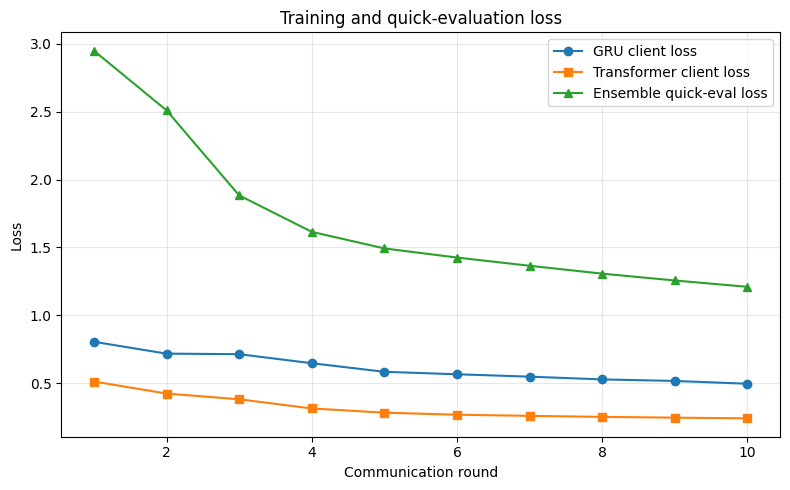

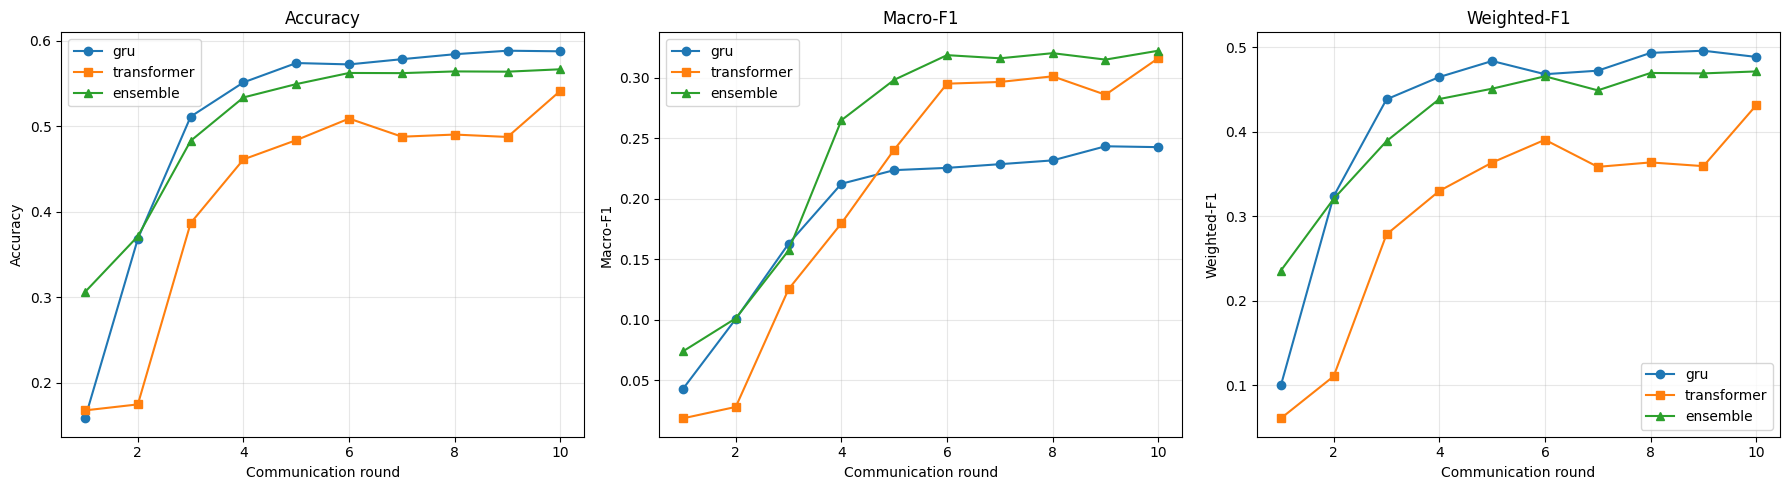

2026-07-18 22:30:01 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-18 22:30:01 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


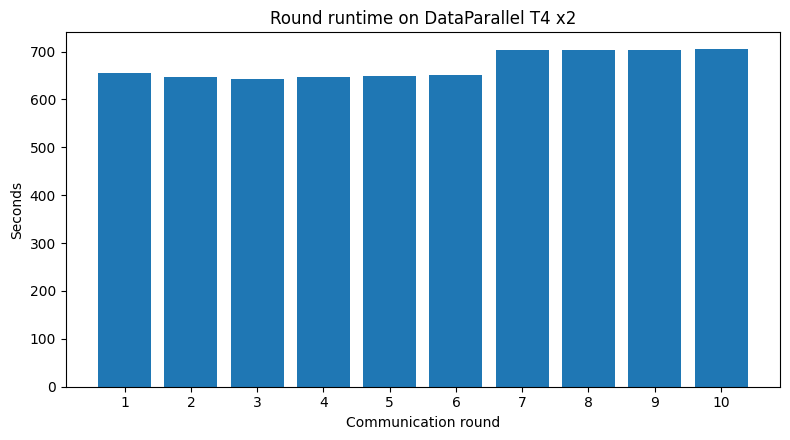

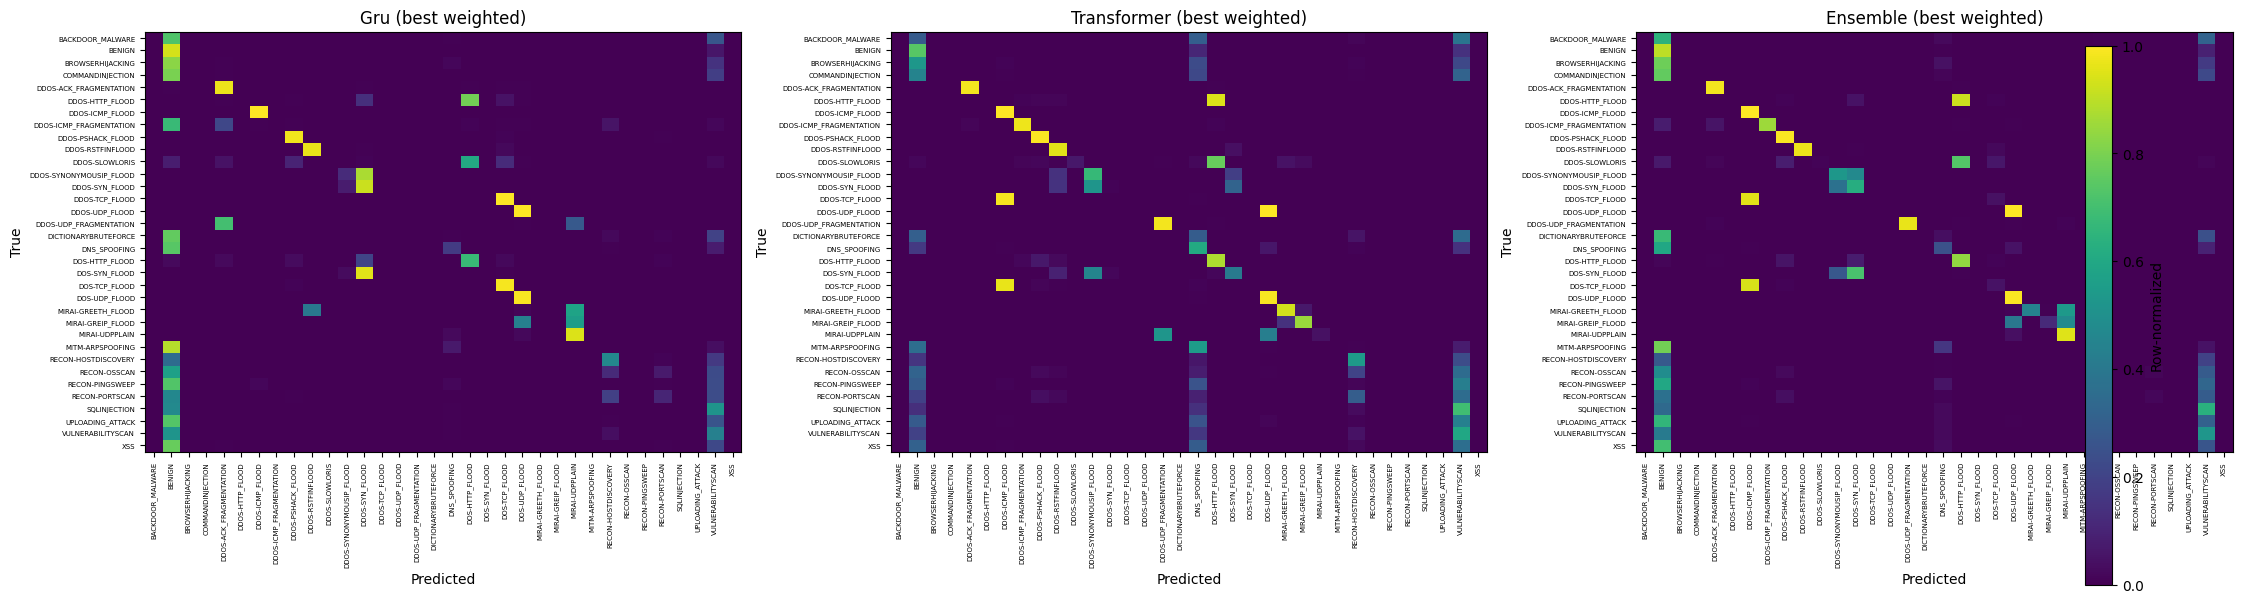

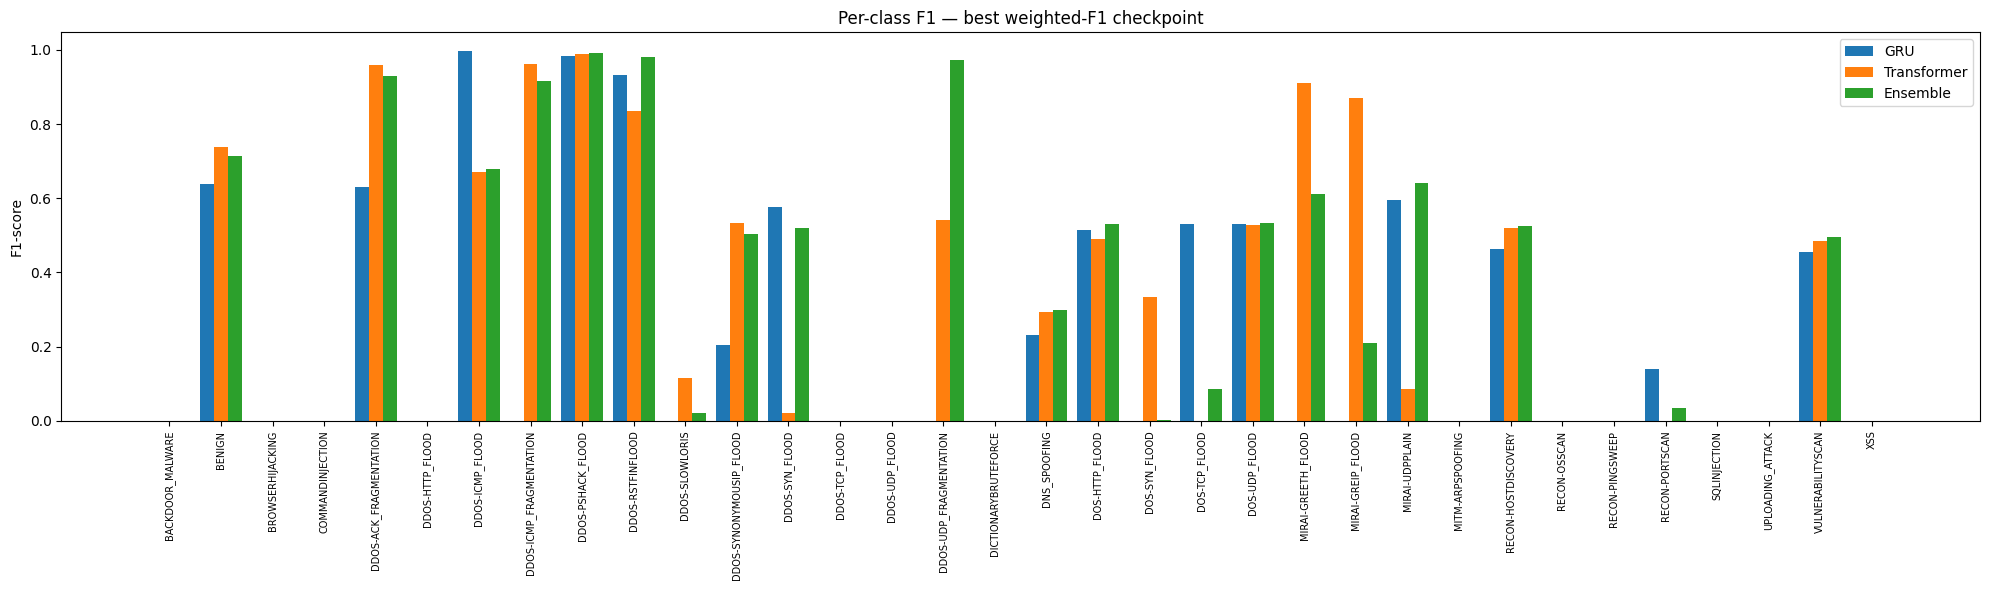

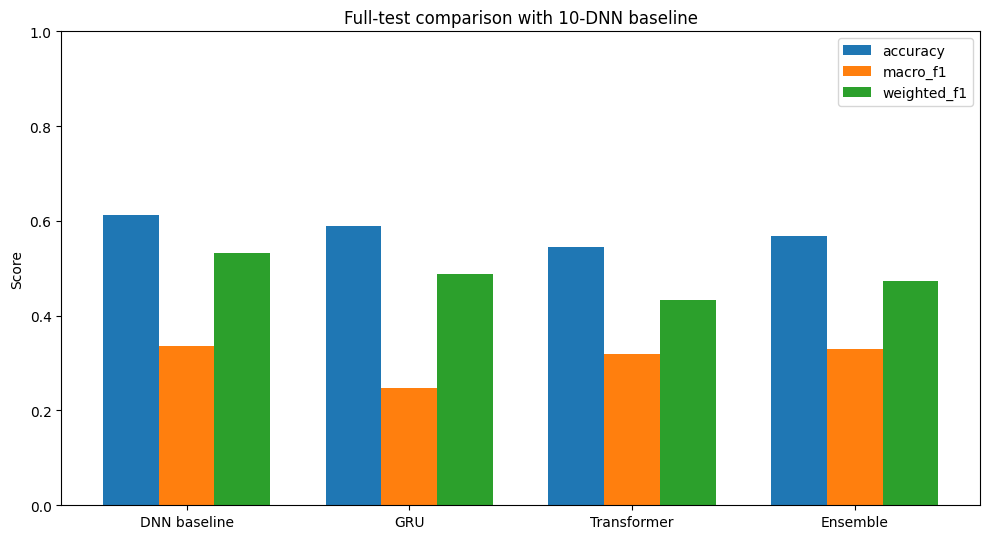

2026-07-18 22:30:07 | INFO | Zero-F1 class counts (best weighted): {'gru': 18, 'transformer': 11, 'ensemble': 13}
2026-07-18 22:30:07 | INFO | Saved diagnostic plots to /kaggle/working/fdids_gru_transformer_run1/artifacts


In [9]:
# ===== Cell 9: Diagnostic plots và so sánh với baseline DNN =====
import matplotlib.pyplot as plt

try:
    history_frame = pd.DataFrame(history)
    rounds = history_frame["round"]

    plt.figure(figsize=(8, 5))
    plt.plot(rounds, history_frame["gru_train_loss"], "o-", label="GRU client loss")
    plt.plot(rounds, history_frame["transformer_train_loss"], "s-", label="Transformer client loss")
    plt.plot(rounds, history_frame["ensemble_eval_loss"], "^-", label="Ensemble quick-eval loss")
    plt.xlabel("Communication round")
    plt.ylabel("Loss")
    plt.title("Training and quick-evaluation loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / "loss_curve.png", dpi=140)
    plt.show()
    plt.close()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for predictor, marker in (("gru", "o"), ("transformer", "s"), ("ensemble", "^")):
        axes[0].plot(rounds, history_frame[f"{predictor}_accuracy"], marker=marker, label=predictor)
        axes[1].plot(rounds, history_frame[f"{predictor}_macro_f1"], marker=marker, label=predictor)
        axes[2].plot(rounds, history_frame[f"{predictor}_weighted_f1"], marker=marker, label=predictor)
    for axis, title, ylabel in zip(
        axes, ("Accuracy", "Macro-F1", "Weighted-F1"), ("Accuracy", "Macro-F1", "Weighted-F1")
    ):
        axis.set_xlabel("Communication round")
        axis.set_ylabel(ylabel)
        axis.set_title(title)
        axis.grid(alpha=0.3)
        axis.legend()
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / "family_ensemble_curves.png", dpi=140)
    plt.show()
    plt.close()

    plt.figure(figsize=(8, 4.5))
    plt.bar(rounds.astype(str), history_frame["round_time_sec"])
    plt.xlabel("Communication round")
    plt.ylabel("Seconds")
    plt.title("Round runtime on DataParallel T4 x2")
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / "round_runtime.png", dpi=140)
    plt.show()
    plt.close()

    labels = list(range(CONFIG["num_classes"]))
    class_names = [id_to_label[index] for index in labels]
    primary_eval = PRIMARY["evaluation"]
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    for axis, predictor in zip(axes, ("gru", "transformer", "ensemble")):
        matrix = confusion_matrix(
            primary_eval["y_true"], primary_eval["predictions"][predictor], labels=labels
        ).astype(float)
        matrix /= matrix.sum(axis=1, keepdims=True).clip(min=1)
        image = axis.imshow(matrix, cmap="viridis", aspect="auto", vmin=0, vmax=1)
        axis.set_title(f"{predictor.title()} (best weighted)")
        axis.set_xlabel("Predicted")
        axis.set_ylabel("True")
        axis.set_xticks(labels)
        axis.set_yticks(labels)
        axis.set_xticklabels(class_names, rotation=90, fontsize=5)
        axis.set_yticklabels(class_names, fontsize=5)
    fig.colorbar(image, ax=axes.ravel().tolist(), fraction=0.015, pad=0.02, label="Row-normalized")
    fig.subplots_adjust(left=0.08, right=0.95, bottom=0.30, top=0.90, wspace=0.25)
    plt.savefig(ARTIFACT_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    per_class_f1 = pd.DataFrame({"class": class_names})
    for predictor in ("gru", "transformer", "ensemble"):
        report = final_reports["best_weighted"][predictor]
        per_class_f1[predictor] = [float(report[name]["f1-score"]) for name in class_names]
    per_class_f1.to_csv(METRICS_DIR / "per_class_f1_best_weighted.csv", index=False)

    positions = np.arange(len(class_names))
    width = 0.27
    plt.figure(figsize=(20, 6))
    plt.bar(positions - width, per_class_f1["gru"], width, label="GRU")
    plt.bar(positions, per_class_f1["transformer"], width, label="Transformer")
    plt.bar(positions + width, per_class_f1["ensemble"], width, label="Ensemble")
    plt.xticks(positions, class_names, rotation=90, fontsize=7)
    plt.ylabel("F1-score")
    plt.title("Per-class F1 — best weighted-F1 checkpoint")
    plt.legend()
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / "per_class_f1.png", dpi=150)
    plt.show()
    plt.close()

    dnn_baseline = {
        "accuracy": 0.6134475033400347,
        "macro_f1": 0.3359587458187551,
        "weighted_f1": 0.531649147086847,
    }
    comparison_models = ["DNN baseline", "GRU", "Transformer", "Ensemble"]
    comparison_metrics = ["accuracy", "macro_f1", "weighted_f1"]
    comparison_values = {
        metric: [dnn_baseline[metric]]
        + [primary_eval["metrics"][predictor][metric] for predictor in ("gru", "transformer", "ensemble")]
        for metric in comparison_metrics
    }
    x_positions = np.arange(len(comparison_models))
    plt.figure(figsize=(10, 5.5))
    for offset, metric in zip((-0.25, 0.0, 0.25), comparison_metrics):
        plt.bar(x_positions + offset, comparison_values[metric], 0.25, label=metric)
    plt.xticks(x_positions, comparison_models)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title("Full-test comparison with 10-DNN baseline")
    plt.legend()
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / "baseline_comparison.png", dpi=140)
    plt.show()
    plt.close()

    zero_f1 = {
        predictor: int((per_class_f1[predictor] == 0).sum())
        for predictor in ("gru", "transformer", "ensemble")
    }
    (METRICS_DIR / "minority_class_diagnostics.json").write_text(
        json.dumps({"zero_f1_classes": zero_f1}, indent=2), encoding="utf-8"
    )
    logger.info("Zero-F1 class counts (best weighted): %s", zero_f1)
    logger.info("Saved diagnostic plots to %s", ARTIFACT_DIR)
except Exception:
    logger.error("Plotting stage failed:\n%s", traceback.format_exc())
    raise


## Nhận định từ baseline DNN và hướng cải thiện tiếp theo

Baseline `10dnn` đạt accuracy `0.6134`, weighted-F1 `0.5316`, nhưng macro-F1 chỉ `0.3360`; 13/34 lớp có F1 bằng 0. Quick-eval loss vẫn giảm và macro-F1 vẫn tăng ở round 10, cho thấy cấu hình 10 round chưa hội tụ. FPR attack-vs-benign là `13.68%`, cao hơn nhiều so với FNR `1.26%`.

Notebook này **không bật các thay đổi dưới đây** để bảo đảm kịch bản 2 chỉ thay đổi họ model và cơ chế aggregation bắt buộc:

1. Tăng từ 10 lên 40 communication round như paper, kết hợp early stopping trên validation độc lập.
2. Không dùng subset của global test để chọn checkpoint trong nghiên cứu chính thức; nên tách validation từ train để tránh test leakage.
3. Thử class-balanced CE, focal loss hoặc balanced sampling vì weighted-F1 đang che khuất thất bại ở lớp hiếm.
4. Thử batch nhỏ hơn 4096 để tăng số bước cập nhật, đặc biệt với client 1 chỉ có 31.520 mẫu.
5. Thực hiện ablation: teacher cùng họ, teacher cross-family ensemble, không KD, không FedProx.
6. Báo cáo riêng chi phí tham số, thời gian round, macro-F1, FPR/FNR và per-class F1; không chỉ accuracy/weighted-F1.

## Output

Toàn bộ kết quả nằm trong `/kaggle/working/fdids_gru_transformer_run1/`:

```text
checkpoints/  # best.pt, best_weighted.pt, best_macro.pt, last.pt, từng round và từng family
logs/         # run.log
metrics/      # summary.json, history.csv, classification reports, confusion matrices
artifacts/    # loss, metric, runtime, confusion matrix, per-class F1 và baseline comparison
```
